# LLM Translation CEFR Results

This notebook analyzes the Universal CEFR classifier outputs on CEFR-targeted LLM translations.

Focus:
- load German, Italian, and Czech classifier prediction files if present
- compare predicted CEFR distributions across requested CEFR bands
- plot one distribution-curve panel per target band
- check whether each target band peaks near its intended CEFR level

Note: the repo currently contains German and Italian classifier outputs. Czech is wired in and will appear automatically once a matching classifier output file exists under `universal-cefr-classifier/outputs/`.


In [1]:
from pathlib import Path
import os
import json

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data-analysis").exists() and (candidate / "universal-cefr-classifier").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repo root from the current working directory.")

REPO_ROOT = find_repo_root(Path.cwd())
FIGURE_DIR = REPO_ROOT / "data-analysis"
MPLCONFIGDIR = FIGURE_DIR / ".mplconfig"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))
os.environ.setdefault("XDG_CACHE_HOME", str(MPLCONFIGDIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")

LEVELS = ["A1", "A2", "B1", "B2", "C1", "C2"]
LEVEL_TO_INT = {level: idx for idx, level in enumerate(LEVELS)}
OUTPUTS_DIR = REPO_ROOT / "universal-cefr-classifier" / "outputs"
COLOR_BY_LANGUAGE = {
    "German": "#d95f02",
    "Italian": "#1b9e77",
    "Czech": "#7570b3",
}

EXPECTED_OUTPUTS = {
    "German": {"prediction_aliases": ["en_de"], "summary_aliases": ["en_de"]},
    "Italian": {"prediction_aliases": ["en_it"], "summary_aliases": ["en_it"]},
    "Czech": {"prediction_aliases": ["en_cs", "en_cz"], "summary_aliases": ["en_cs", "en_cz"]},
}

FIGURE_DIR


PosixPath('/Users/ericbennett/Desktop/github/language-learning-llms/data-analysis')

In [2]:
def find_first_match(aliases: list[str], suffix: str) -> Path | None:
    for alias in aliases:
        matches = sorted(OUTPUTS_DIR.glob(f"*{alias}*{suffix}"))
        if matches:
            return matches[0]
    return None

def load_language_frames():
    frames = {}
    metadata_rows = []
    missing_languages = []

    for language, aliases in EXPECTED_OUTPUTS.items():
        prediction_path = find_first_match(aliases["prediction_aliases"], "classifier_predictions.jsonl")
        summary_path = find_first_match(aliases["summary_aliases"], "classifier_summary.json")

        if prediction_path is None:
            missing_languages.append(language)
            metadata_rows.append({
                "language": language,
                "prediction_path": None,
                "summary_path": None,
                "rows": 0,
                "exact_match_accuracy": np.nan,
            })
            continue

        df = pd.read_json(prediction_path, lines=True)
        df = df[df["requested_cefr"].isin(LEVELS) & df["predicted_cefr"].isin(LEVELS)].copy()
        df["requested_cefr"] = pd.Categorical(df["requested_cefr"], categories=LEVELS, ordered=True)
        df["predicted_cefr"] = pd.Categorical(df["predicted_cefr"], categories=LEVELS, ordered=True)
        df["requested_index"] = df["requested_cefr"].map(LEVEL_TO_INT).astype(int)
        df["predicted_index"] = df["predicted_cefr"].map(LEVEL_TO_INT).astype(int)

        exact_match_accuracy = np.nan
        if summary_path and summary_path.exists():
            exact_match_accuracy = json.loads(summary_path.read_text()).get("exact_match_accuracy", np.nan)

        frames[language] = df
        metadata_rows.append({
            "language": language,
            "prediction_path": str(prediction_path.relative_to(REPO_ROOT)),
            "summary_path": str(summary_path.relative_to(REPO_ROOT)) if summary_path else None,
            "rows": len(df),
            "exact_match_accuracy": exact_match_accuracy,
        })

    metadata = pd.DataFrame(metadata_rows)
    return frames, metadata, missing_languages

language_frames, file_summary, missing_languages = load_language_frames()

if not language_frames:
    raise FileNotFoundError("No classifier prediction files were found in universal-cefr-classifier/outputs/.")

if missing_languages:
    display(Markdown(
        "**Missing languages:** "
        + ", ".join(missing_languages)
        + "<br>These plots will update automatically once matching classifier output files appear in `universal-cefr-classifier/outputs/`."
    ))

display(file_summary.style.format({"exact_match_accuracy": "{:.3f}"}))


**Missing languages:** Czech<br>These plots will update automatically once matching classifier output files appear in `universal-cefr-classifier/outputs/`.

,language,prediction_path,summary_path,rows,exact_match_accuracy
0,German,universal-cefr-classifier/outputs/en_de_cefr_candidates_250_classifier_predictions.jsonl,universal-cefr-classifier/outputs/en_de_cefr_candidates_250_classifier_summary.json,900,0.261
1,Italian,universal-cefr-classifier/outputs/en_it_cefr_candidates_250_classifier_predictions.jsonl,universal-cefr-classifier/outputs/en_it_cefr_candidates_250_classifier_summary.json,900,0.207
2,Czech,None,None,0,nan


In [3]:
def count_matrix(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby(["requested_cefr", "predicted_cefr"], observed=False)
        .size()
        .unstack(fill_value=0)
        .reindex(index=LEVELS, columns=LEVELS, fill_value=0)
    )

count_tables = {language: count_matrix(df) for language, df in language_frames.items()}
normalized_tables = {
    language: table.div(table.sum(axis=1), axis=0)
    for language, table in count_tables.items()
}

request_count_table = (
    pd.concat(
        [df.assign(language=language) for language, df in language_frames.items()],
        ignore_index=True,
    )
    .groupby(["language", "requested_cefr"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=LEVELS, fill_value=0)
)

peak_rows = []
for language, matrix in normalized_tables.items():
    for requested in LEVELS:
        row = matrix.loc[requested, LEVELS]
        peak_rows.append({
            "language": language,
            "requested_cefr": requested,
            "peak_predicted_cefr": row.idxmax(),
            "peak_share": float(row.max()),
            "mean_predicted_level_index": float(np.dot(np.arange(len(LEVELS)), row.values)),
        })

peak_table = pd.DataFrame(peak_rows)

display(Markdown("### Rows per requested CEFR band"))
display(request_count_table)
display(Markdown("### Peak predicted band for each target"))
display(peak_table.style.format({"peak_share": "{:.3f}", "mean_predicted_level_index": "{:.2f}"}))


### Rows per requested CEFR band

requested_cefr,A1,A2,B1,B2,C1,C2
language,,,,,,
German,150,150,150,150,150,150
Italian,150,150,150,150,150,150


### Peak predicted band for each target

,language,requested_cefr,peak_predicted_cefr,peak_share,mean_predicted_level_index
0,German,A1,A2,0.500,1.51
1,German,A2,B1,0.587,2.03
2,German,B1,B2,0.387,3.15
3,German,B2,C2,0.500,4.13
4,German,C1,C2,0.493,4.16
5,German,C2,C2,0.547,4.27
6,Italian,A1,B1,0.693,1.75
7,Italian,A2,B1,0.853,2.07
8,Italian,B1,B1,0.700,2.30
9,Italian,B2,B1,0.520,2.53


## Per-Language Heatmaps

Each heatmap row is a requested CEFR band and each column is the predicted CEFR band.
Values are row-normalized, so each row sums to 1.0. A strong diagonal means the classifier is landing near the intended target level.


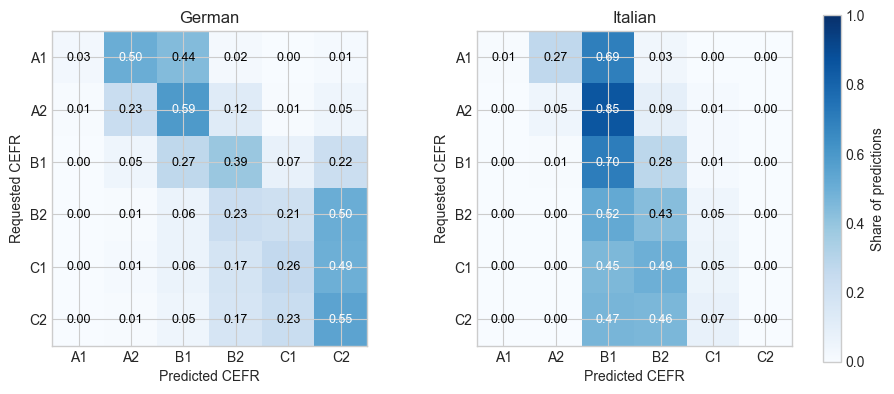

PosixPath('data-analysis/llm_cefr_language_heatmaps.png')

In [4]:
num_languages = len(normalized_tables)
fig, axes = plt.subplots(
    1,
    num_languages,
    figsize=(5 * num_languages, 4.5),
    squeeze=False,
)

for ax, (language, matrix) in zip(axes.flat, normalized_tables.items()):
    image = ax.imshow(matrix.values, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(language)
    ax.set_xticks(range(len(LEVELS)), LEVELS)
    ax.set_yticks(range(len(LEVELS)), LEVELS)
    ax.set_xlabel("Predicted CEFR")
    ax.set_ylabel("Requested CEFR")

    for row_idx in range(len(LEVELS)):
        for col_idx in range(len(LEVELS)):
            value = matrix.iloc[row_idx, col_idx]
            ax.text(
                col_idx,
                row_idx,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=9,
                color="white" if value > 0.45 else "black",
            )

fig.subplots_adjust(right=0.92, wspace=0.35)
fig.colorbar(image, ax=axes.ravel().tolist(), fraction=0.03, pad=0.04, label="Share of predictions")
heatmap_path = FIGURE_DIR / "llm_cefr_language_heatmaps.png"
fig.savefig(heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

heatmap_path.relative_to(REPO_ROOT)


## Six Target-Band Distribution Curves

Each panel corresponds to one requested CEFR target. The x-axis is the classifier's predicted band, and the dashed vertical line marks the ideal target band.
These are discrete category distributions, so the lines connect category probabilities rather than fitting a continuous parabola.


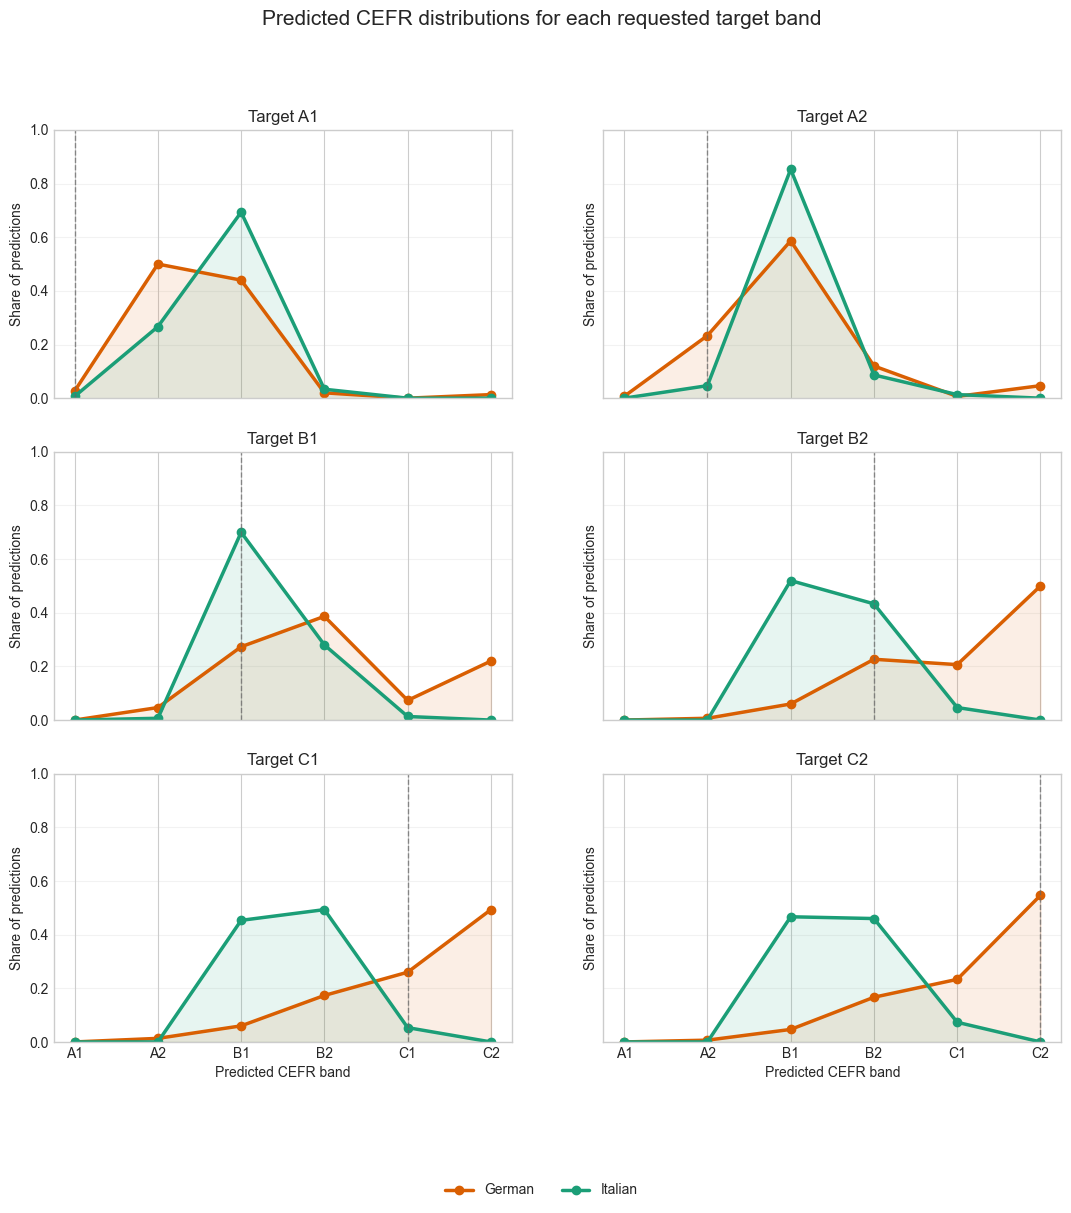

PosixPath('data-analysis/llm_cefr_target_band_curves.png')

In [10]:
fig, axes = plt.subplots(
    3, 2,
    figsize=(13, 12),
    sharex=True,
    sharey=True,
    constrained_layout=False  # 👈 important
)

x = np.arange(len(LEVELS))

for ax, requested in zip(axes.flat, LEVELS):
    for language, matrix in normalized_tables.items():
        y = matrix.loc[requested, LEVELS].to_numpy(dtype=float)
        color = COLOR_BY_LANGUAGE.get(language)
        ax.plot(x, y, marker="o", linewidth=2.5, label=language, color=color)
        ax.fill_between(x, y, alpha=0.10, color=color)
    ax.axvline(LEVEL_TO_INT[requested], linestyle="--", linewidth=1, color="#666666", alpha=0.7)
    ax.set_title(f"Target {requested}")
    ax.set_xticks(x, LEVELS)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share of predictions")
    ax.grid(axis="y", alpha=0.25)

for ax in axes[-1, :]:
    ax.set_xlabel("Predicted CEFR band")

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    ncol=len(labels),
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02)  # 👈 slightly below figure
)

# 👇 make room for legend
plt.subplots_adjust(bottom=0.12)

fig.suptitle("Predicted CEFR distributions for each requested target band", fontsize=15)

curve_path = FIGURE_DIR / "llm_cefr_target_band_curves.png"
fig.savefig(curve_path, dpi=200, bbox_inches="tight")
plt.show()

curve_path.relative_to(REPO_ROOT)

## Calibration View

This compares the mean predicted CEFR index against the requested CEFR index.
The diagonal is perfect alignment. Points below the line indicate that the classifier is undershooting the requested level on average.


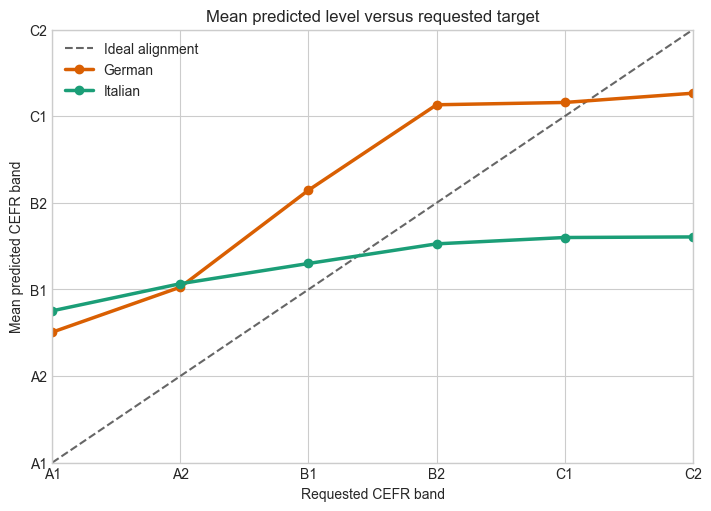

,language,requested_cefr,requested_index,mean_predicted_index
0,German,A1,0,1.506667
1,German,A2,1,2.026667
2,German,B1,2,3.146667
3,German,B2,3,4.133333
4,German,C1,4,4.160000
5,German,C2,5,4.266667
6,Italian,A1,0,1.753333
7,Italian,A2,1,2.066667
8,Italian,B1,2,2.300000
9,Italian,B2,3,2.526667


PosixPath('data-analysis/llm_cefr_mean_level_calibration.png')

In [6]:
calibration_rows = []
for language, matrix in normalized_tables.items():
    for requested in LEVELS:
        distribution = matrix.loc[requested, LEVELS].to_numpy(dtype=float)
        calibration_rows.append({
            "language": language,
            "requested_cefr": requested,
            "requested_index": LEVEL_TO_INT[requested],
            "mean_predicted_index": float(np.dot(np.arange(len(LEVELS)), distribution)),
        })

calibration_df = pd.DataFrame(calibration_rows)

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
ax.plot(x, x, linestyle="--", color="#666666", linewidth=1.5, label="Ideal alignment")

for language, group in calibration_df.groupby("language"):
    ax.plot(
        group["requested_index"],
        group["mean_predicted_index"],
        marker="o",
        linewidth=2.5,
        color=COLOR_BY_LANGUAGE.get(language),
        label=language,
    )

ax.set_xticks(x, LEVELS)
ax.set_yticks(x, LEVELS)
ax.set_xlim(0, len(LEVELS) - 1)
ax.set_ylim(0, len(LEVELS) - 1)
ax.set_xlabel("Requested CEFR band")
ax.set_ylabel("Mean predicted CEFR band")
ax.set_title("Mean predicted level versus requested target")
ax.legend(frameon=False)

calibration_path = FIGURE_DIR / "llm_cefr_mean_level_calibration.png"
fig.savefig(calibration_path, dpi=200, bbox_inches="tight")
plt.show()

display(calibration_df)
calibration_path.relative_to(REPO_ROOT)
